In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)

# Connexion à la base de données
conn = psycopg2.connect(
    dbname="langdetect_projet",
    user="langdetect_user",
    password="motdepasse",
    host="localhost",
    port="5432"
)

print("Connexion réussie")

Connexion réussie


In [3]:
import warnings
warnings.filterwarnings('ignore')

# Charger tous les articles en mémoire
df = pd.read_sql("SELECT id, langue, longueur FROM documents ORDER BY langue", conn)

print(f"Nombre total d'articles : {len(df)}")
print(f"\nRépartition par langue :")
print(df.groupby('langue')['id'].count().to_string())

Nombre total d'articles : 1500

Répartition par langue :
langue
es    500
fr    500
pt    500


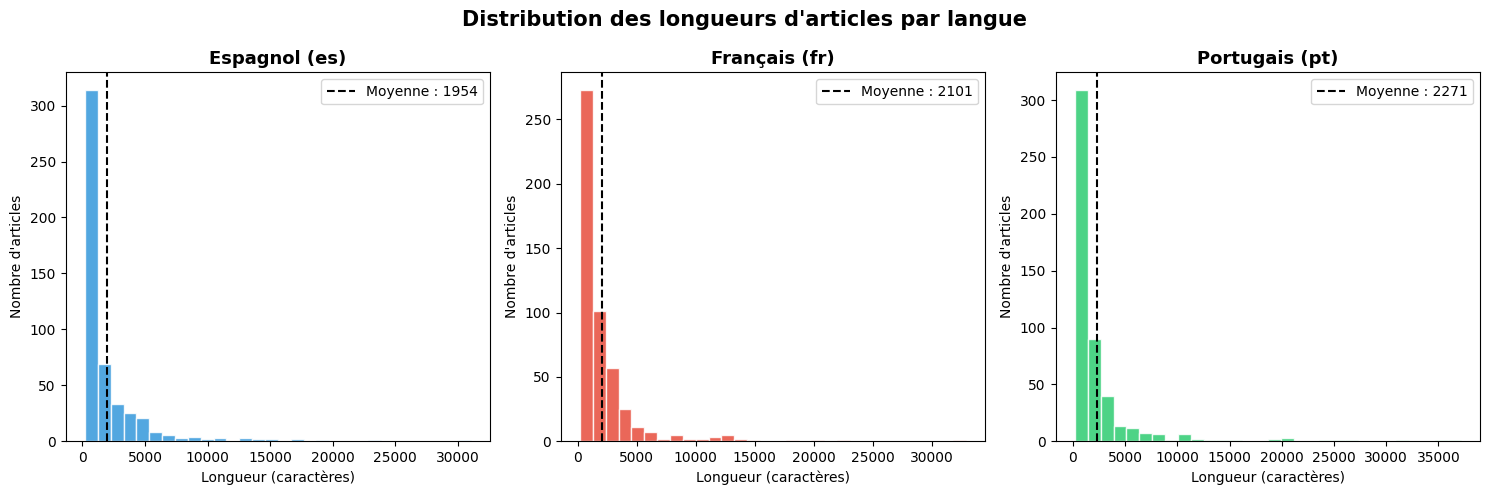

Graphique sauvegardé


In [7]:
# Distribution des longueurs par langue
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

langues = ['es', 'fr', 'pt']
couleurs = ['#3498db', '#e74c3c', '#2ecc71']
noms = ['Espagnol', 'Français', 'Portugais']

for i, (langue, couleur, nom) in enumerate(zip(langues, couleurs, noms)):
    data = df[df['langue'] == langue]['longueur']
    axes[i].hist(data, bins=30, color=couleur, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{nom} ({langue})', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Longueur (caractères)')
    axes[i].set_ylabel('Nombre d\'articles')
    axes[i].axvline(data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Moyenne : {int(data.mean())}')
    axes[i].legend()

plt.suptitle('Distribution des longueurs d\'articles par langue', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('distribution_longueurs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé")

In [8]:
# Statistiques détaillées par langue
stats = df.groupby('langue')['longueur'].agg([
    ('Minimum', 'min'),
    ('Maximum', 'max'),
    ('Moyenne', 'mean'),
    ('Médiane', 'median'),
    ('Écart-type', 'std')
]).round(0).astype(int)

# Renommer les langues pour l'affichage
stats.index = stats.index.map({'es': 'Espagnol', 'fr': 'Français', 'pt': 'Portugais'})

print("=== Statistiques des longueurs d'articles (en caractères) ===\n")
print(stats.to_string())

=== Statistiques des longueurs d'articles (en caractères) ===

           Minimum  Maximum  Moyenne  Médiane  Écart-type
langue                                                   
Espagnol       201    31036     1955      726        3140
Français       201    32874     2101     1131        3063
Portugais      201    37134     2271      988        4220


In [9]:
# Analyse des bigrammes les plus fréquents par langue
from collections import Counter

def extraire_bigrammes(texte):
    """Extrait tous les bigrammes de caractères d'un texte."""
    texte = texte.lower()
    return [texte[i:i+2] for i in range(len(texte)-1)]

# Charger les textes complets
df_textes = pd.read_sql("SELECT langue, contenu FROM documents", conn)

print("=== Top 10 des bigrammes par langue ===\n")

for langue, nom in [('es', 'Espagnol'), ('fr', 'Français'), ('pt', 'Portugais')]:
    textes = df_textes[df_textes['langue'] == langue]['contenu']
    
    # Compter tous les bigrammes
    compteur = Counter()
    for texte in textes:
        compteur.update(extraire_bigrammes(texte))
    
    # Afficher les 10 plus fréquents
    print(f"--- {nom} ({langue}) ---")
    for bigramme, freq in compteur.most_common(10):
        print(f"  '{bigramme}' : {freq:,}")
    print()

=== Top 10 des bigrammes par langue ===

--- Espagnol (es) ---
  'e ' : 27,423
  'a ' : 26,221
  ' d' : 21,594
  'de' : 21,475
  ' e' : 18,678
  's ' : 17,870
  'o ' : 17,239
  'n ' : 16,974
  'en' : 16,672
  ' l' : 13,130

--- Français (fr) ---
  'e ' : 44,650
  ' d' : 25,700
  's ' : 24,020
  ' l' : 19,296
  't ' : 18,420
  'es' : 18,054
  'de' : 17,273
  'le' : 15,484
  'en' : 14,761
  'on' : 13,145

--- Portugais (pt) ---
  'o ' : 34,589
  'a ' : 31,163
  'e ' : 30,720
  ' d' : 24,999
  's ' : 21,907
  'de' : 19,451
  ' e' : 17,685
  ' a' : 16,335
  ' p' : 14,019
  ' c' : 13,954



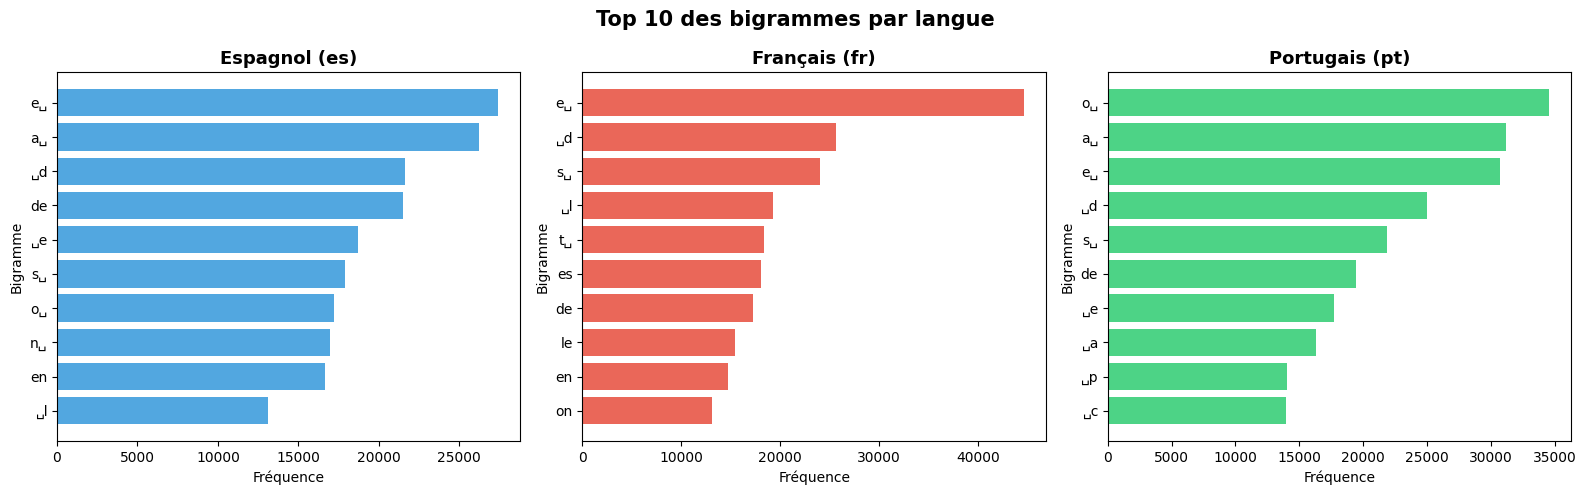

Graphique sauvegardé


In [10]:
# Graphique comparatif des bigrammes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

langues_info = [
    ('es', 'Espagnol', '#3498db'),
    ('fr', 'Français', '#e74c3c'),
    ('pt', 'Portugais', '#2ecc71')
]

for i, (langue, nom, couleur) in enumerate(langues_info):
    textes = df_textes[df_textes['langue'] == langue]['contenu']
    
    compteur = Counter()
    for texte in textes:
        compteur.update(extraire_bigrammes(texte))
    
    top10 = compteur.most_common(10)
    bigrammes = [b[0].replace(' ', '␣') for b in top10]
    frequences = [b[1] for b in top10]
    
    axes[i].barh(bigrammes[::-1], frequences[::-1], color=couleur, alpha=0.85)
    axes[i].set_title(f'{nom} ({langue})', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Fréquence')
    axes[i].set_ylabel('Bigramme')

plt.suptitle('Top 10 des bigrammes par langue', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('bigrammes_top10.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé")

In [11]:
# Résumé global du corpus actuel
print("=" * 55)
print("      RÉSUMÉ DU CORPUS (langues disponibles)")
print("=" * 55)

total = len(df)
print(f"\nNombre total d'articles : {total}")
print(f"Nombre de langues       : {df['langue'].nunique()}")
print(f"\nDétail par langue :")
print(f"{'Langue':<12} {'Articles':>10} {'Moy. chars':>12} {'Min':>8} {'Max':>8}")
print("-" * 55)

for langue, nom in [('es','Espagnol'), ('fr','Français'), ('pt','Portugais')]:
    subset = df[df['langue'] == langue]['longueur']
    print(f"{nom:<12} {len(subset):>10} {int(subset.mean()):>12} {subset.min():>8} {subset.max():>8}")

print("-" * 55)
print(f"\nObservations :")
print(f"  - Distribution asymétrique : majorité de courts articles")
print(f"  - Tous les articles > 200 caractères (filtre appliqué)")
print(f"  - Encodage UTF-8 vérifié pour les 3 langues")
print(f"  - Langues restantes à collecter : en, de, nl, ar, ru")
print(f"\nStatut : corpus partiel (3/8 langues)")

      RÉSUMÉ DU CORPUS (langues disponibles)

Nombre total d'articles : 1500
Nombre de langues       : 3

Détail par langue :
Langue         Articles   Moy. chars      Min      Max
-------------------------------------------------------
Espagnol            500         1954      201    31036
Français            500         2101      201    32874
Portugais           500         2271      201    37134
-------------------------------------------------------

Observations :
  - Distribution asymétrique : majorité de courts articles
  - Tous les articles > 200 caractères (filtre appliqué)
  - Encodage UTF-8 vérifié pour les 3 langues
  - Langues restantes à collecter : en, de, nl, ar, ru

Statut : corpus partiel (3/8 langues)


In [12]:
# Comptage du nombre de mots par langue
print("=== Nombre de mots par langue ===\n")
print(f"{'Langue':<12} {'Total mots':>12} {'Moy. mots/article':>20} {'Min':>8} {'Max':>8}")
print("-" * 65)

for langue, nom in [('es','Espagnol'), ('fr','Français'), ('pt','Portugais')]:
    textes = df_textes[df_textes['langue'] == langue]['contenu']
    nb_mots = textes.apply(lambda t: len(t.split()))
    print(f"{nom:<12} {nb_mots.sum():>12,} {int(nb_mots.mean()):>20} {nb_mots.min():>8} {nb_mots.max():>8}")

print("-" * 65)

=== Nombre de mots par langue ===

Langue         Total mots    Moy. mots/article      Min      Max
-----------------------------------------------------------------
Espagnol          161,382                  322       29     5170
Français          171,088                  342       27     5397
Portugais         183,812                  367       30     5877
-----------------------------------------------------------------


In [13]:
# Vérification des doublons via le checksum
df_checksums = pd.read_sql(
    "SELECT langue, checksum, COUNT(*) as nb FROM documents GROUP BY langue, checksum HAVING COUNT(*) > 1",
    conn
)

print("=== Vérification des doublons ===\n")
if len(df_checksums) == 0:
    print("Aucun doublon détecté dans le corpus.")
else:
    print(f"{len(df_checksums)} doublons détectés :")
    print(df_checksums)

print("\n=== Vérification de l'encodage UTF-8 ===\n")

erreurs_encodage = 0
for langue, nom in [('es','Espagnol'), ('fr','Français'), ('pt','Portugais')]:
    textes = df_textes[df_textes['langue'] == langue]['contenu']
    erreurs = 0
    for texte in textes:
        try:
            texte.encode('utf-8').decode('utf-8')
        except UnicodeDecodeError:
            erreurs += 1
    statut = "OK" if erreurs == 0 else f"{erreurs} erreurs"
    print(f"  {nom:<12} : {statut}")
    erreurs_encodage += erreurs

print(f"\nBilan : {'Tout le corpus est en UTF-8 valide.' if erreurs_encodage == 0 else f'{erreurs_encodage} erreurs détectées.'}")

=== Vérification des doublons ===

Aucun doublon détecté dans le corpus.

=== Vérification de l'encodage UTF-8 ===

  Espagnol     : OK
  Français     : OK
  Portugais    : OK

Bilan : Tout le corpus est en UTF-8 valide.


In [14]:
# Résumé des observations — à copier dans le rapport
print("""
=== OBSERVATIONS POUR LE RAPPORT ===

1. TAILLE DU CORPUS
   - 3 langues disponibles à ce stade : espagnol, français, portugais
   - 500 articles par langue, soit 1500 articles au total
   - Volume total : ~516 000 mots (environ 172 000 mots par langue)

2. DISTRIBUTION DES LONGUEURS
   - Distribution fortement asymétrique pour les 3 langues :
     la majorité des articles est courte (< 2000 caractères)
     mais quelques articles très longs tirent la moyenne vers le haut.
   - Longueur moyenne : ~2100 caractères (entre 1954 et 2271 selon la langue)
   - Longueur médiane : ~950 caractères (bien inférieure à la moyenne)
   - Tous les articles respectent le filtre minimum de 200 caractères.

3. QUALITÉ DES DONNÉES
   - Aucun doublon détecté (vérification par checksum SHA-256)
   - Encodage UTF-8 valide pour les 3 langues
   - Aucun article supprimé lors du nettoyage

4. SIGNATURES LINGUISTIQUES (N-GRAMMES)
   - Les bigrammes les plus fréquents sont clairement distincts entre langues :
     * Espagnol : 'e ', 'a ', 'de' dominent
     * Français : 'e ' écrase les autres (e muet en fin de mot)
     * Portugais : 'o ', 'a ', 'e ' dominent (terminaisons typiques)
   - Ces signatures confirment que les n-grammes de caractères
     sont de bons indicateurs pour la détection de langue.

5. LANGUES RESTANTES
   - Anglais, allemand, néerlandais, arabe, russe en cours de collecte.
   - Le corpus sera mis à jour une fois ces langues disponibles.
""")


=== OBSERVATIONS POUR LE RAPPORT ===

1. TAILLE DU CORPUS
   - 3 langues disponibles à ce stade : espagnol, français, portugais
   - 500 articles par langue, soit 1500 articles au total
   - Volume total : ~516 000 mots (environ 172 000 mots par langue)

2. DISTRIBUTION DES LONGUEURS
   - Distribution fortement asymétrique pour les 3 langues :
     la majorité des articles est courte (< 2000 caractères)
     mais quelques articles très longs tirent la moyenne vers le haut.
   - Longueur moyenne : ~2100 caractères (entre 1954 et 2271 selon la langue)
   - Longueur médiane : ~950 caractères (bien inférieure à la moyenne)
   - Tous les articles respectent le filtre minimum de 200 caractères.

3. QUALITÉ DES DONNÉES
   - Aucun doublon détecté (vérification par checksum SHA-256)
   - Encodage UTF-8 valide pour les 3 langues
   - Aucun article supprimé lors du nettoyage

4. SIGNATURES LINGUISTIQUES (N-GRAMMES)
   - Les bigrammes les plus fréquents sont clairement distincts entre langues :
 